<a href="https://colab.research.google.com/github/AugustusKH/DeepLearning_architectures/blob/main/1_single_cell_persistent_homology_computation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single-cell persistent homology computation

April 2026

Author: Pakorn Sagulkoo

In this code, we performed Vietoris-Rips filtration on a benchmark single-cell dataset using different topological representations derived from the raw count expression matrix. Subsequently, we visualised the corresponding persistence diagrams.

Moreover, we evaluated whether these representations are trainable and differentiable during optimisation via neural network backpropagation.

## Import the relevant libraries

In [3]:
# Import the libraries
import random
import numpy as np
import pandas as pd
import keras
import tensorflow as tf
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
import gudhi as gd
import scTopoDEC as stc
from scTopoDEC.utils import density_scale, get_topo_representation

## Load the dataset

We use paul15 from scanpy as aa benchmark dataet in this code. Further detail of this dataset can be found in this ([link](https://scanpy.readthedocs.io/en/stable/generated/scanpy.datasets.paul15.html))

In [4]:
# Load single-cell dataset
adata = sc.datasets.paul15()

  0%|          | 0.00/9.82M [00:00<?, ?B/s]

We performed some standard single-cell analysis to look overall patterns of the dataset

/tmp/ipykernel_640/1258752148.py:12: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata_orig, n_top_genes=2000, flavor='seurat_v3')


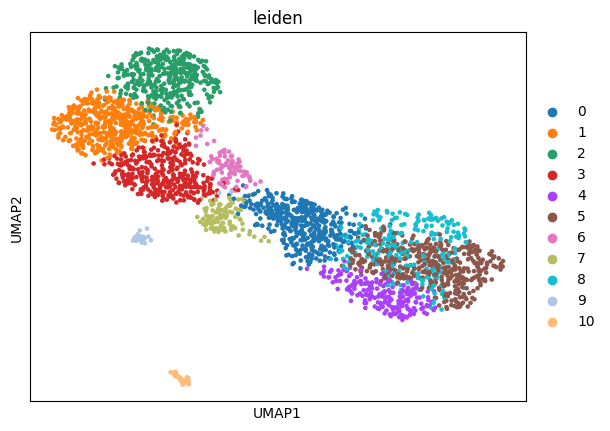

In [54]:
# scRNA-seq standard pipeline analysis
# 1. Quality control
adata_orig = adata.copy()
sc.pp.filter_genes(adata_orig, min_cells=5)

# 2. Normalisation
adata_orig.layers["counts"] = adata_orig.X.copy() # Saving count data
sc.pp.normalize_total(adata_orig)
sc.pp.log1p(adata_orig)

# 3. Feature selection
sc.pp.highly_variable_genes(adata_orig, n_top_genes=2000, flavor='seurat_v3')

# 4. PCA and UMAP
sc.tl.pca(adata_orig)
sc.pp.neighbors(adata_orig)
sc.tl.umap(adata_orig)

# 5. Clustering
sc.tl.leiden(adata_orig, flavor="igraph", n_iterations=2)
sc.pl.umap(adata_orig, color=["leiden"])

In [5]:
# Copy the original object
adata_stc = adata.copy()

## Get topological representation and persistent diagrams

In this tutorial, we use six different topological representations—raw, PCA, UMAP, kNN-based Euclidean distance (kNN), kNN-based effective resistance distance (eff_res), and kNN-based diffusion distance (diffusion)—to compute filtrations and generate persistence diagrams.

In [12]:
# Define a function to preprocess topological representations and persistent diagrams

def ph_input_test(adata, batch_size=64, n_components=30, k=15, t=8, max_edge_length=2):
  """
  This function is used to calculate filtration and show
  persistent diagrams (PGs) based on raw adata input with
  several representation. We show only four modes: raw, PCA, UMAP,
  kNN, eff_res, and diffusion

  # Arguments
  adata : class:`anndata.AnnData`
    A single-cell object. Must include raw counts in `.X` or `.raw.X`.
  batch_size : `int`, optional (default: 32)
    Number of samples per gradient update.
  n_components : `int`, optional (default: 30)
    The number of dimensions to retain when using 'pca', 'umap', or their corresponding distance
    modes for the input representation.
  k : `int`, optional (default: 15)
    The number of nearest neighbors used to construct the adjacency matrix for graph-based modes
    (e.g., 'knn', 'eff_res', and 'diffusion').
  t : `int`, optional (default: 8)
    The diffusion time (number of power iterations) applied to the transition matrix when calculating
    diffusion distances.
  maximum_edge_length : `float`, optional (default: 2.)
    The filtration cutoff. Limits the distance at which points are connected.
    Prevents OOM errors by ignoring very long-distance edges.

  # Return
    Calculates and displays a 2x2 grid of Persistence Diagrams for different
    representation modes.
  """
  # Set global seeds for reproducibility
  random.seed(0)
  np.random.seed(0)
  tf.random.set_seed(0)
  keras.utils.set_random_seed(0)

  represent_modes = ('raw', 'pca', 'umap', 'knn', 'eff_res', 'diffusion')

  # Initialize the Matplotlib figure
  fig, axes = plt.subplots(3, 2, figsize=(10, 12))
  axes = axes.flatten()

  for i, mode in enumerate(represent_modes):
    print(f"Representation with: {mode}")

    # Get representation via utility wrapper
    topo_input = get_topo_representation(adata, input_mode=mode,
                                         n_components=n_components,
                                         k=k, t=t)

    # Sample the representation
    n_cells = topo_input.shape[0]
    indices = np.random.choice(n_cells, size=batch_size, replace=False)

    # Handle distance matrices vs coordinates for sampling
    if topo_input.ndim == 2 and topo_input.shape[0] == topo_input.shape[1]:
      topo_sample = topo_input[np.ix_(indices, indices)]
    else:
      topo_sample = topo_input[indices, :]

    # Data scaling to ensure unit average distance
    topo_sample_scale, _ = density_scale(tf.cast(topo_sample, tf.float32), batch_size)
    topo_sample_scale = topo_sample_scale.numpy()

    # Show min-max distance before and after scaling
    dist_matrix = pairwise_distances(topo_sample)
    print("Before scaling")
    print(f"Min dist: {dist_matrix[dist_matrix > 0].min()}")
    print(f"Max dist: {dist_matrix.max()}")

    dist_matrix = pairwise_distances(topo_sample_scale)
    print("\nAfter scaling")
    print(f"Min dist: {dist_matrix[dist_matrix > 0].min()}")
    print(f"Max dist: {dist_matrix.max()}\n")

    # Calculate persistence diagram with GUDHI
    if mode in ['knn', 'eff_res', 'diffusion']:
      rips = gd.RipsComplex(distance_matrix=topo_sample_scale, max_edge_length=max_edge_length)
    else:
      rips = gd.RipsComplex(points=topo_sample_scale, max_edge_length=max_edge_length)

    st = rips.create_simplex_tree(max_dimension=2)
    dgm = st.persistence()

    # Plot to the specific subplot index
    gd.plot_persistence_diagram(dgm, axes=axes[i])
    axes[i].set_title(f"Mode: {mode.upper()}")

  plt.tight_layout()
  plt.show()

  return

Representation with: raw
Before scaling
Min dist: 25.45584487915039
Max dist: 363.5972900390625

After scaling
Min dist: 0.20316271483898163
Max dist: 2.901865005493164

Representation with: pca
Before scaling
Min dist: 9.484940528869629
Max dist: 433.56787109375

After scaling
Min dist: 0.08314798772335052
Max dist: 3.800793409347534

Representation with: umap
Before scaling
Min dist: 0.05311969667673111
Max dist: 18.3570613861084

After scaling
Min dist: 0.007115768268704414
Max dist: 2.459043025970459

Representation with: knn
Before scaling
Min dist: 1.7320507764816284
Max dist: 7.211102485656738

After scaling
Min dist: 34.149112701416016
Max dist: 142.17408752441406

Representation with: eff_res
Before scaling
Min dist: 5.8900818381060146e-05
Max dist: 0.037168772233424296

After scaling
Min dist: 0.04256975278258324
Max dist: 26.86322593688965

Representation with: diffusion
Before scaling
Min dist: 0.0010040801944890695
Max dist: 20.165558379021242

After scaling
Min dist: 0.00

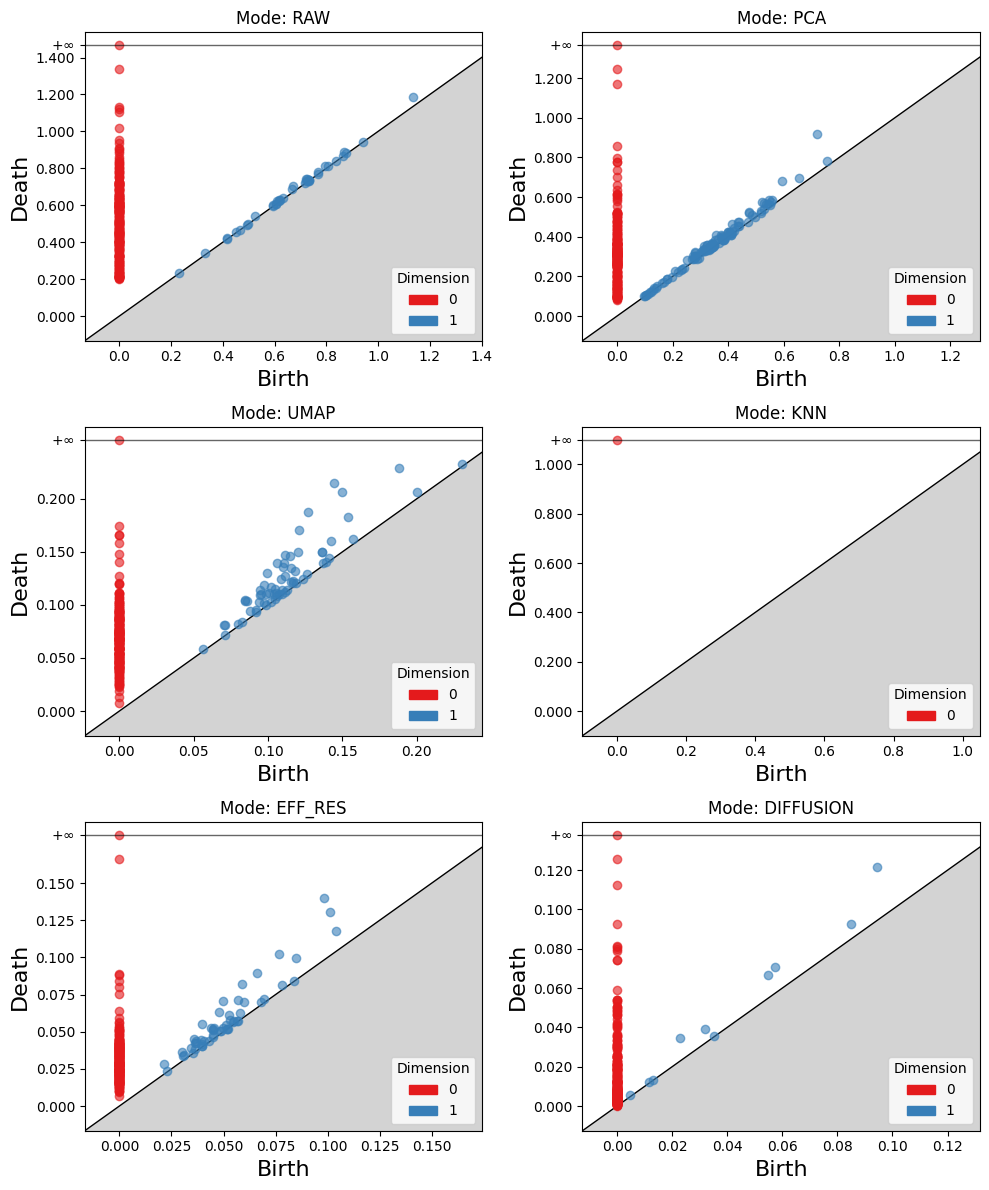

In [13]:
# Run the filtration and visualise persistent diagrams
ph_input_test(adata_stc, batch_size=256, n_components=30, k=100, t=64, max_edge_length=2)

From the results, we observe that the raw count and PCA representations fail to detect important H1 simplicial complexes (loops), as their birth and death intervals are nearly identical, with most H1 points lying close to the diagonal in the persistence diagrams. Moreover, the kNN-based Euclidean distance representation also fails to capture meaningful H1 structures.

In contrast, prominent H1 complexes can be identified in the UMAP, effective resistance (eff_res), and diffusion representations, as indicated by several H1 points located above the diagonal. Therefore, we suggest using these representations for training the model.  

## Test the trainable of topological representation

We tested functions from the GUDHI library to evaluate whether they can be used to train our neural network. Two distance metrics, namely Mean Squared Error (MSE) and Wasserstein distance, were employed to assess trainability and differentiability during the optimisation process.

In this section we generate 2D random point clounds and show what happen if we perform the persistent optimisation with TensorFlow.

In [25]:
# Import the relevant libraries
from tqdm import tqdm
import gudhi.wasserstein as gw
from gudhi.tensorflow import LowerStarSimplexTreeLayer, CubicalLayer, RipsLayer

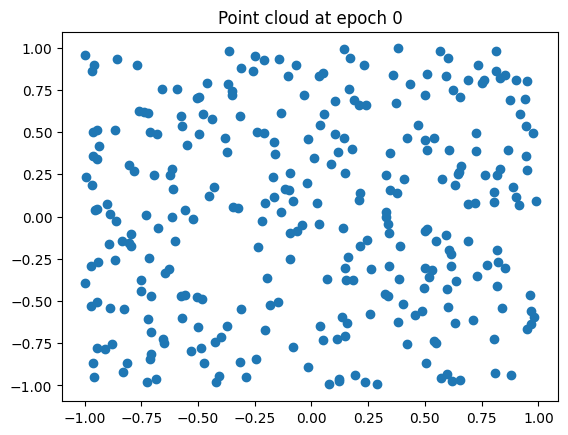

In [14]:
# General 2D point clounds and visualise them
np.random.seed(1)
Xinit = np.array(np.random.uniform(high=1., low=-1., size=(300,2)), dtype=np.float32)

plt.figure()
plt.scatter(Xinit[:,0], Xinit[:,1])
plt.title('Point cloud at epoch 0')
plt.show()

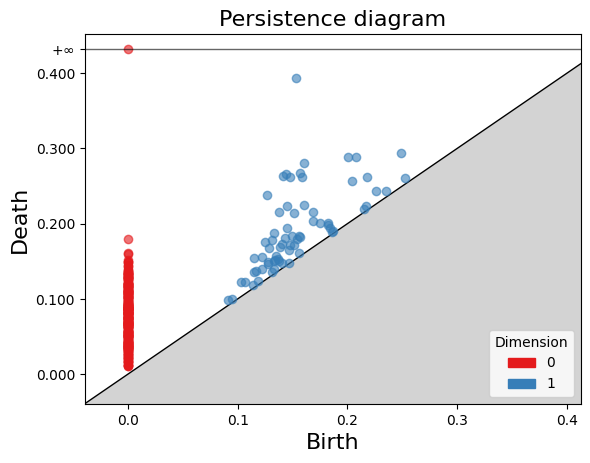

In [15]:
# Visualise the persistent diagram
st = gd.RipsComplex(points=Xinit, max_edge_length=1.).create_simplex_tree(max_dimension=2)
dgm = st.persistence()
plot = gd.plot_persistence_diagram(dgm)

Here, we will prepare the point clounds to be compatitble and trainable with tensorflow optimisation.

In [17]:
# Convert the point clounds to tensor format and generate the filtration layer
X = tf.Variable(initial_value=Xinit, trainable=True)
layer = RipsLayer(maximum_edge_length=1., homology_dimensions=[1])

In [18]:
# Define the learning rate and optimiser
lr = tf.keras.optimizers.schedules.InverseTimeDecay(initial_learning_rate=1e-1, decay_steps=10, decay_rate=.01)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.)

### MSE distance

We use the MSE loss to maximise the distances to the diagonal of the persistence diagram points.

In [ ]:
# Run the training step
losses, dgms = [], []
for epoch in tqdm(range(200+1)):

    with tf.GradientTape() as tape:
        dgm = layer.call(X)[0][0]
        # Opposite of the squared distances to the diagonal
        persistence_loss = -tf.math.reduce_sum(tf.square(.5*(dgm[:,1]-dgm[:,0])))
        # Unit square regularization
        regularization = tf.reduce_sum(tf.maximum(tf.abs(X)-1, 0))
        loss = persistence_loss + regularization
    gradients = tape.gradient(loss, [X])

    # We also apply a small random noise to the gradient to ensure convergence
    np.random.seed(epoch)
    gradients[0] = gradients[0] + np.random.normal(loc=0., scale=.001, size=gradients[0].shape)

    optimizer.apply_gradients(zip(gradients, [X]))
    losses.append(loss.numpy())
    dgms.append(dgm)

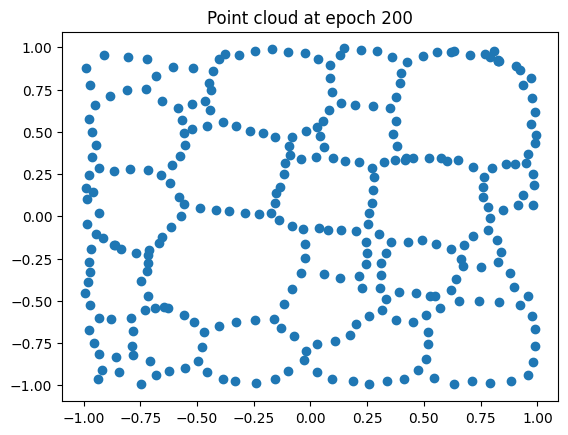

In [20]:
# Visualise the point clouds after training
plt.figure()
plt.scatter(X.numpy()[:,0], X.numpy()[:,1])
plt.title('Point cloud at epoch ' + str(epoch))
plt.show()

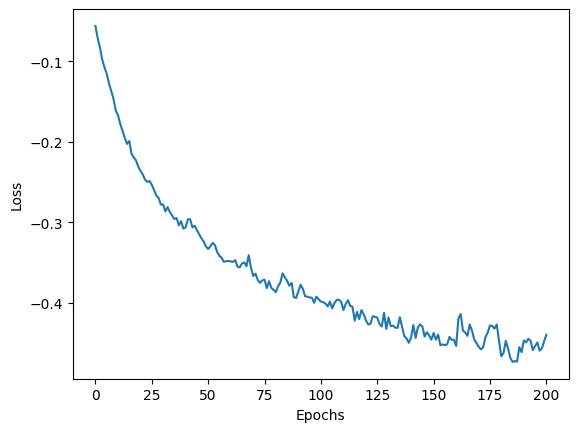

In [21]:
# Visualise the loss and the sequence of iterates
plt.figure()
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

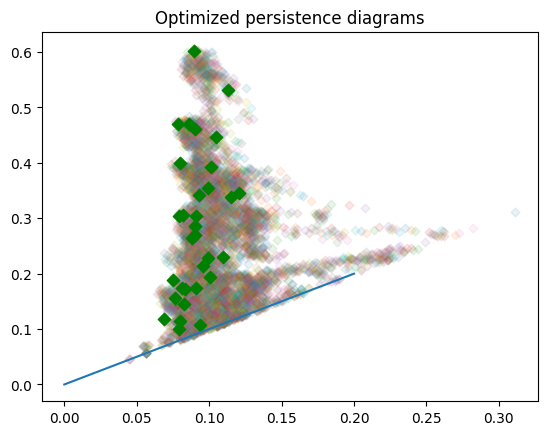

In [22]:
# Visualise the persistent diagram after training
plt.figure()
for dg in dgms[:5:-1]:
    plt.scatter(dg[:,0], dg[:,1], s=20, marker='D', alpha=0.1)
plt.scatter(dgms[-1][:,0], dgms[-1][:,1], s=40, marker='D', c='green')
plt.plot([-0.,.2], [-0.,.2])
plt.title('Optimized persistence diagrams')
plt.show()

### Wasserstein distance

Compared to the MSE loss, the Wasserstein distance introduces an implicit reference through optimal transport, effectively matching point clouds and guiding the training process towards this reference for improved convergence.

In [49]:
# Generate the artificial reference
target_dgm = tf.constant([[0.0, 10.0]] * 10, dtype=tf.float32)

In [ ]:
# Run the training step
losses, dgms = [], []

for epoch in tqdm(range(200+1)):
    with tf.GradientTape() as tape:
        dgm = layer.call(X)[0][0]

        w_loss = gw.wasserstein_distance(
            dgm,
            target_dgm,
            order=1.0,
            enable_autodiff=True,
            keep_essential_parts=False # Essential for autodiff compatibility
        )

        regularization = tf.reduce_sum(tf.maximum(tf.abs(X)-1, 0))
        loss = w_loss + regularization

    gradients = tape.gradient(loss, [X])

    # Add noise for convergence
    np.random.seed(epoch)
    gradients[0] += np.random.normal(loc=0., scale=.001, size=gradients[0].shape)

    optimizer.apply_gradients(zip(gradients, [X]))
    losses.append(loss.numpy())
    dgms.append(dgm)

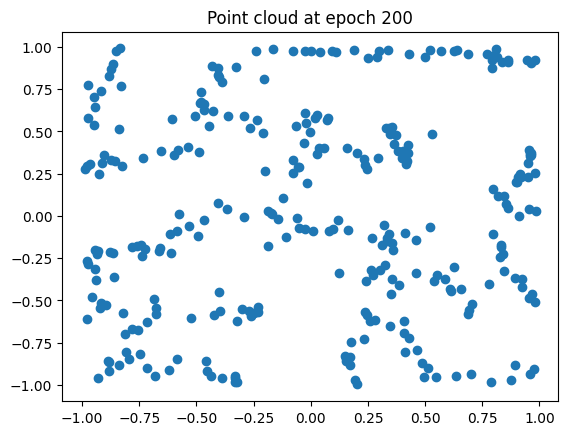

In [51]:
# Visualise the point clouds after training
plt.figure()
plt.scatter(X.numpy()[:,0], X.numpy()[:,1])
plt.title('Point cloud at epoch ' + str(epoch))
plt.show()

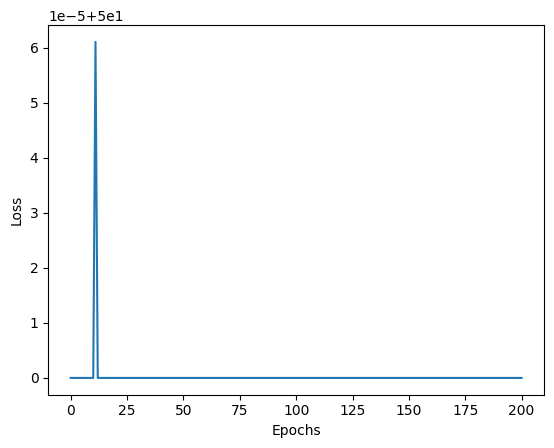

In [52]:
# Visualise the loss and the sequence of iterates
plt.figure()
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

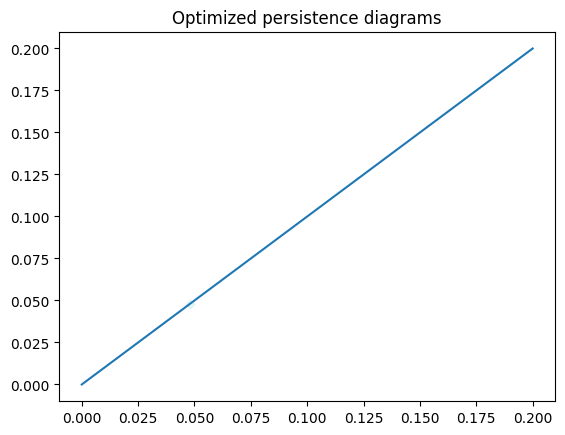

In [53]:
# Visualise the persistent diagram after training
plt.figure()
for dg in dgms[:5:-1]:
    plt.scatter(dg[:,0], dg[:,1], s=20, marker='D', alpha=0.1)
plt.scatter(dgms[-1][:,0], dgms[-1][:,1], s=40, marker='D', c='green')
plt.plot([-0.,.2], [-0.,.2])
plt.title('Optimized persistence diagrams')
plt.show()

From the result, we have proved that we can use the Wasserstein distance to train the model.